# Phase 7: Uplift Baseline

Treatment-control incremental impact analysis using `mart_campaign_response`.

## Decision Flow

1. Keep only features available at assignment time or before assignment.
2. Drop all post-treatment leakage columns such as opens, clicks, conversions, and realized revenue.
3. Fit separate response models for treated and control groups.
4. Score each customer with estimated uplift = `p(response | treat) - p(response | control)`.
5. Rank customers by uplift score and evaluate observed uplift by decile on the test set.
6. Export scored samples, decile tables, model comparison, and uplift charts.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

CWD = Path.cwd().resolve()
ROOT = CWD if (CWD / 'data').exists() else CWD.parent
DATA = ROOT / 'data' / 'processed'
OUT = ROOT / 'outputs'
OUT.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_DECILES = 10

print(f'Root: {ROOT}')
print(f'Data exists: {DATA.exists()} | Out: {OUT}')

Root: C:\Users\USER\Documents\Python Projects\retail-intelligence
Data exists: True | Out: C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs


In [3]:
df = pd.read_csv(DATA / 'mart_campaign_response.csv', parse_dates=['assignment_datetime'])

df['is_treatment'] = df['treatment_flag'].astype(int)
df['is_control'] = df['control_flag'].astype(int)
df['response'] = df['response_flag_30d'].astype(int)

post_treatment_exact = {
    'customer_id',
    'assignment_datetime',
    'treatment_flag',
    'control_flag',
    'is_treatment',
    'is_control',
    'response',
    'response_flag_30d',
    'response_bucket',
    'campaign_response_rank',
    'revenue_decile_within_campaign',
    'delivered_flag',
    'open_flag',
    'click_flag',
    'unsubscribe_flag',
    'conversion_within_7d',
    'conversion_within_30d',
    'revenue_within_7d',
    'revenue_within_30d',
    'source_event_rows',
}
post_treatment_contains = ['conversion', 'revenue_within', 'response', 'click', 'open', 'unsubscribe']

candidate_cols = [c for c in df.columns if c not in post_treatment_exact]
leakage_rows = []
approved_features = []

for col in candidate_cols:
    reasons = []
    lower_col = col.lower()
    for token in post_treatment_contains:
        if token in lower_col:
            reasons.append(f'post_treatment_contains:{token}')
            break
    action = 'drop' if reasons else 'keep'
    if action == 'keep':
        approved_features.append(col)
    leakage_rows.append({'feature': col, 'action': action, 'reasons': ';'.join(reasons) if reasons else 'none'})

leakage_audit = pd.DataFrame(leakage_rows).sort_values(['action', 'feature']).reset_index(drop=True)

df = df.sort_values('assignment_datetime').reset_index(drop=True)
split_ix = int(len(df) * 0.8)
train_df = df.iloc[:split_ix].copy()
test_df = df.iloc[split_ix:].copy()

combo_train = train_df[['is_treatment', 'response']].drop_duplicates().shape[0]
combo_test = test_df[['is_treatment', 'response']].drop_duplicates().shape[0]
if combo_train < 4 or combo_test < 4:
    from sklearn.model_selection import train_test_split
    strata = df['is_treatment'].astype(str) + '_' + df['response'].astype(str)
    train_df, test_df = train_test_split(
        df, test_size=0.2, random_state=RANDOM_STATE, stratify=strata
    )
    split_strategy = 'stratified_random_80_20_treatment_response'
else:
    split_strategy = 'time_ordered_80_20_by_assignment_datetime'

X_train = train_df[approved_features].copy()
X_test = test_df[approved_features].copy()
y_train = train_df['response'].copy()
y_test = test_df['response'].copy()
treat_train = train_df['is_treatment'].copy()
treat_test = test_df['is_treatment'].copy()

train_df['assignment_month'] = train_df['assignment_datetime'].dt.month
train_df['assignment_dayofweek'] = train_df['assignment_datetime'].dt.dayofweek
train_df['assignment_hour'] = train_df['assignment_datetime'].dt.hour
test_df['assignment_month'] = test_df['assignment_datetime'].dt.month
test_df['assignment_dayofweek'] = test_df['assignment_datetime'].dt.dayofweek
test_df['assignment_hour'] = test_df['assignment_datetime'].dt.hour

for derived_col in ['assignment_month', 'assignment_dayofweek', 'assignment_hour']:
    if derived_col not in X_train.columns:
        X_train[derived_col] = train_df[derived_col]
        X_test[derived_col] = test_df[derived_col]
        approved_features.append(derived_col)

leakage_path = OUT / 'phase7_uplift_leakage_audit.csv'
approved_path = OUT / 'phase7_uplift_approved_features.csv'
leakage_audit.to_csv(leakage_path, index=False)
pd.DataFrame({'feature': approved_features}).drop_duplicates().to_csv(approved_path, index=False)

group_summary = train_df.groupby('is_treatment')['response'].agg(['count', 'mean']).reset_index()
group_summary['group'] = group_summary['is_treatment'].map({1: 'treatment', 0: 'control'})

print(f'Split strategy: {split_strategy}')
print(f'Train rows: {len(train_df)} | Test rows: {len(test_df)}')
print(f'Approved features: {len(pd.Index(approved_features).unique())}')
print(f'Train treatment share: {treat_train.mean():.4f} | Test treatment share: {treat_test.mean():.4f}')
display(group_summary)
print(leakage_path)
print(approved_path)

Split strategy: time_ordered_80_20_by_assignment_datetime
Train rows: 82074 | Test rows: 20519
Approved features: 14
Train treatment share: 0.8380 | Test treatment share: 0.8300


,is_treatment,count,mean,group
0,0,13293,0.155872,control
1,1,68781,0.197889,treatment


C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase7_uplift_leakage_audit.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase7_uplift_approved_features.csv


In [4]:
def two_proportion_z_test(success_a, n_a, success_b, n_b):
    p_pool = (success_a + success_b) / (n_a + n_b)
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_a + 1 / n_b))
    z = (success_a / n_a - success_b / n_b) / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return float(z), float(p)

overall = (
    df.groupby('is_treatment')['response']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count': 'n', 'sum': 'responders', 'mean': 'response_rate'})
    .reset_index()
 )
overall['group'] = overall['is_treatment'].map({1: 'treatment', 0: 'control'})

treat_row = overall.loc[overall['is_treatment'] == 1].iloc[0]
control_row = overall.loc[overall['is_treatment'] == 0].iloc[0]
uplift = float(treat_row['response_rate'] - control_row['response_rate'])
z_stat, p_value = two_proportion_z_test(
    treat_row['responders'], treat_row['n'], control_row['responders'], control_row['n']
 )

balance = (
    df.groupby('is_treatment')[['pre_90d_orders', 'pre_90d_revenue', 'pre_90d_aov']]
    .mean()
    .reset_index()
 )
balance['group'] = balance['is_treatment'].map({1: 'treatment', 0: 'control'})

print(f'Overall uplift: {uplift:.4f}')
print(f'Two-proportion z-test: z={z_stat:.3f}, p={p_value:.6f}')
display(overall[['group', 'n', 'responders', 'response_rate']])
display(balance[['group', 'pre_90d_orders', 'pre_90d_revenue', 'pre_90d_aov']])

Overall uplift: 0.0424
Two-proportion z-test: z=12.728, p=0.000000


,group,n,responders,response_rate
0,control,16782,2641,0.157371
1,treatment,85811,17141,0.199753


,group,pre_90d_orders,pre_90d_revenue,pre_90d_aov
0,control,2.137588,335.457026,132.141597
1,treatment,2.036907,343.200479,132.999419


C:\Users\USER\AppData\Local\Temp\ipykernel_14972\3000762149.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
C:\Users\USER\AppData\Local\Temp\ipykernel_14972\3000762149.py:82: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  qini_like_area = np.trapz(
C:\Users\USER\AppData\Local\Temp\ipykernel_14972\3000762149.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the gr

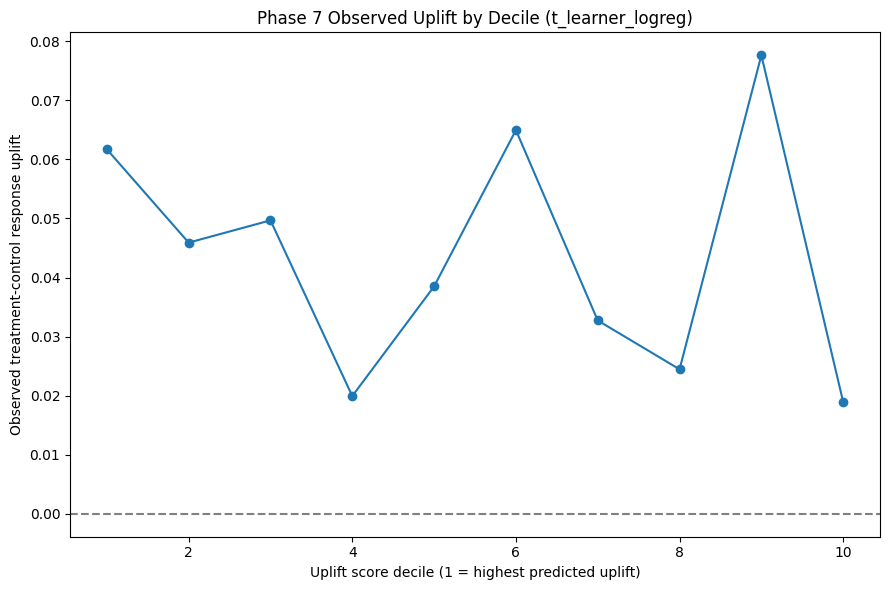

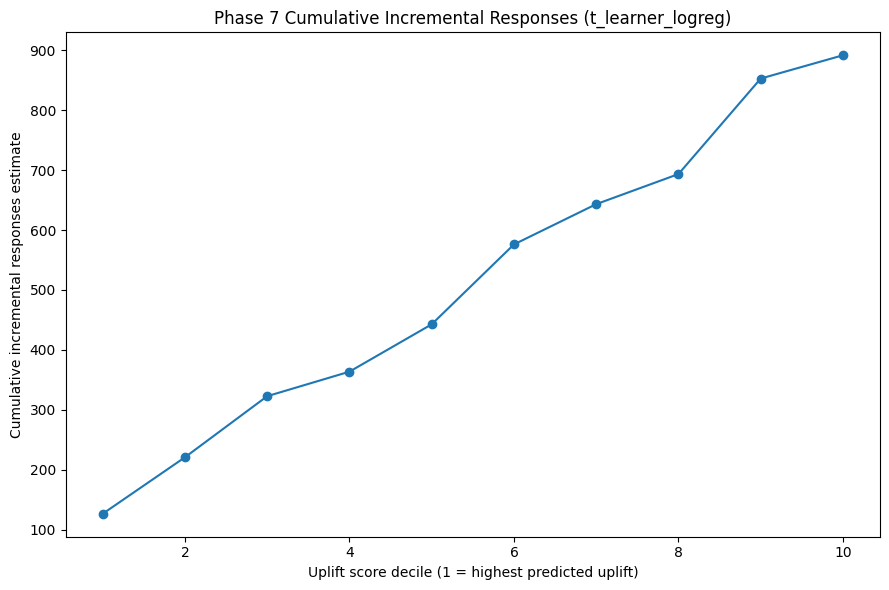

Model comparison:


,model,split_strategy,approved_feature_count,test_rows,overall_ate_test,top3_decile_observed_uplift,top5_decile_observed_uplift,total_incremental_responses_est,qini_like_area,response_auc_proxy,response_pr_auc_proxy
0,t_learner_logreg,time_ordered_80_20_by_assignment_datetime,14,20519,0.042382,0.052438,0.043151,891.501735,462.425345,0.523094,0.210602
1,t_learner_rf,time_ordered_80_20_by_assignment_datetime,14,20519,0.042382,0.039793,0.053662,927.082018,502.475366,0.505210,0.201861



Best-model deciles:


,uplift_decile,n_total,n_treatment,n_control,response_rate_treatment,response_rate_control,mean_uplift_score,model,observed_uplift,incremental_responses_est,cumulative_incremental_responses
0,1,2052.0,1596.0,456.0,0.213033,0.151316,0.007576,t_learner_logreg,0.061717,126.642857,126.642857
1,2,2052.0,1667.0,385.0,0.199160,0.153247,-0.001522,t_learner_logreg,0.045913,94.214327,220.857184
2,3,2052.0,1622.0,430.0,0.198520,0.148837,-0.006041,t_learner_logreg,0.049683,101.949795,322.806979
3,4,2052.0,1717.0,335.0,0.205009,0.185075,-0.011665,t_learner_logreg,0.019934,40.904792,363.711771
4,5,2052.0,1742.0,310.0,0.225603,0.187097,-0.017284,t_learner_logreg,0.038506,79.014274,442.726045
5,6,2051.0,1763.0,288.0,0.221214,0.156250,-0.020147,t_learner_logreg,0.064964,133.240836,575.966881
6,7,2052.0,1736.0,316.0,0.194124,0.161392,-0.022239,t_learner_logreg,0.032732,67.166103,643.132984
7,8,2052.0,1722.0,330.0,0.203252,0.178788,-0.023970,t_learner_logreg,0.024464,50.200443,693.333427
8,9,2052.0,1751.0,301.0,0.203883,0.126246,-0.025865,t_learner_logreg,0.077638,159.312454,852.645881
9,10,2052.0,1714.0,338.0,0.208285,0.189349,-0.029163,t_learner_logreg,0.018936,38.855855,891.501735



Top scored customers sample:


,campaign_id,campaign_name,customer_id,assignment_datetime,is_treatment,response,pred_response_if_treated,pred_response_if_control,uplift_score,rank,uplift_decile
0,CMP012,Year End Save,C024740,2025-12-10 18:42:00,1,0,0.595501,0.543404,0.052096,1,1
1,CMP011,Peak Season Holdout Test,C043722,2025-11-09 20:06:00,1,0,0.562927,0.522479,0.040448,2,1
2,CMP011,Peak Season Holdout Test,C016557,2025-11-09 20:19:00,1,0,0.558377,0.521457,0.036921,3,1
3,CMP011,Peak Season Holdout Test,C016116,2025-11-09 20:45:00,1,1,0.508452,0.475372,0.033079,4,1
4,CMP011,Peak Season Holdout Test,C023287,2025-11-09 21:57:00,1,1,0.505558,0.474570,0.030988,5,1
5,CMP012,Year End Save,C030176,2025-12-10 17:10:00,0,0,0.567967,0.537331,0.030636,6,1
6,CMP011,Peak Season Holdout Test,C031241,2025-11-09 20:40:00,1,0,0.504925,0.474592,0.030333,7,1
7,CMP011,Peak Season Holdout Test,C041675,2025-11-09 21:16:00,0,1,0.507794,0.478577,0.029217,8,1
8,CMP011,Peak Season Holdout Test,C024588,2025-11-09 20:16:00,1,0,0.502727,0.474106,0.028622,9,1
9,CMP011,Peak Season Holdout Test,C039402,2025-11-09 20:24:00,0,0,0.502074,0.473961,0.028113,10,1


Artifacts written:
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase7_uplift_leakage_audit.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase7_uplift_approved_features.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase7_uplift_overall_summary.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase7_uplift_model_comparison.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase7_uplift_decile_summary.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase7_uplift_scored_sample_top500.csv
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase7_uplift_by_decile.png
C:\Users\USER\Documents\Python Projects\retail-intelligence\outputs\phase7_uplift_cumulative_incremental.png


In [6]:
num_cols = X_train.select_dtypes(include=['number', 'bool']).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=['number', 'bool']).columns.tolist()

pre = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]),
            num_cols,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore')),
            ]),
            cat_cols,
        ),
    ]
 )

model_specs = {
    't_learner_logreg': LogisticRegression(max_iter=1200, class_weight='balanced', random_state=RANDOM_STATE),
    't_learner_rf': RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

comparison_rows = []
decile_frames = []
best_payload = None

for model_name, estimator in model_specs.items():
    treated_pipe = Pipeline([('pre', pre), ('model', estimator)])
    control_pipe = Pipeline([('pre', pre), ('model', estimator.__class__(**estimator.get_params()))])

    treated_pipe.fit(X_train.loc[treat_train == 1], y_train.loc[treat_train == 1])
    control_pipe.fit(X_train.loc[treat_train == 0], y_train.loc[treat_train == 0])

    p_treat = treated_pipe.predict_proba(X_test)[:, 1]
    p_control = control_pipe.predict_proba(X_test)[:, 1]
    uplift_score = p_treat - p_control

    scored = test_df[['campaign_id', 'campaign_name', 'customer_id', 'assignment_datetime', 'is_treatment', 'response']].copy()
    scored['pred_response_if_treated'] = p_treat
    scored['pred_response_if_control'] = p_control
    scored['uplift_score'] = uplift_score
    scored = scored.sort_values('uplift_score', ascending=False).reset_index(drop=True)
    scored['rank'] = np.arange(1, len(scored) + 1)
    scored['uplift_decile'] = pd.qcut(scored['rank'], q=N_DECILES, labels=np.arange(1, N_DECILES + 1)).astype(int)

    decile = (
        scored.groupby('uplift_decile')
        .apply(
            lambda g: pd.Series({
                'n_total': len(g),
                'n_treatment': int((g['is_treatment'] == 1).sum()),
                'n_control': int((g['is_treatment'] == 0).sum()),
                'response_rate_treatment': g.loc[g['is_treatment'] == 1, 'response'].mean(),
                'response_rate_control': g.loc[g['is_treatment'] == 0, 'response'].mean(),
                'mean_uplift_score': g['uplift_score'].mean(),
            })
        )
        .reset_index()
    )
    decile['model'] = model_name
    decile['observed_uplift'] = decile['response_rate_treatment'] - decile['response_rate_control']
    decile['incremental_responses_est'] = decile['observed_uplift'] * decile['n_total']
    decile['cumulative_incremental_responses'] = decile['incremental_responses_est'].cumsum()

    top3 = decile.nsmallest(3, 'uplift_decile')
    top5 = decile.nsmallest(5, 'uplift_decile')
    weighted_top3_uplift = np.average(top3['observed_uplift'], weights=top3['n_total'])
    weighted_top5_uplift = np.average(top5['observed_uplift'], weights=top5['n_total'])
    qini_like_area = np.trapz(
        decile['cumulative_incremental_responses'],
        x=decile['uplift_decile'] / N_DECILES,
    )

    overall_response_auc = roc_auc_score(y_test, (p_treat + p_control) / 2)
    overall_pr_auc = average_precision_score(y_test, (p_treat + p_control) / 2)

    comparison_rows.append({
        'model': model_name,
        'split_strategy': split_strategy,
        'approved_feature_count': len(pd.Index(approved_features).unique()),
        'test_rows': len(scored),
        'overall_ate_test': uplift,
        'top3_decile_observed_uplift': float(weighted_top3_uplift),
        'top5_decile_observed_uplift': float(weighted_top5_uplift),
        'total_incremental_responses_est': float(decile['incremental_responses'].sum()) if 'incremental_responses' in decile.columns else float(decile['incremental_responses_est'].sum()),
        'qini_like_area': float(qini_like_area),
        'response_auc_proxy': float(overall_response_auc),
        'response_pr_auc_proxy': float(overall_pr_auc),
    })

    decile_frames.append(decile)

    if best_payload is None or weighted_top3_uplift > best_payload['top3_uplift']:
        best_payload = {
            'model_name': model_name,
            'treated_pipe': treated_pipe,
            'control_pipe': control_pipe,
            'scored': scored,
            'decile': decile,
            'top3_uplift': weighted_top3_uplift,
        }

comparison = pd.DataFrame(comparison_rows).sort_values('top3_decile_observed_uplift', ascending=False).reset_index(drop=True)
deciles_all = pd.concat(decile_frames, ignore_index=True)

best_model_name = comparison.iloc[0]['model']
best_scored = best_payload['scored']
best_decile = best_payload['decile'].copy()

plt.figure(figsize=(9, 6))
plot_df = best_decile.sort_values('uplift_decile')
plt.plot(plot_df['uplift_decile'], plot_df['observed_uplift'], marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.title(f'Phase 7 Observed Uplift by Decile ({best_model_name})')
plt.xlabel('Uplift score decile (1 = highest predicted uplift)')
plt.ylabel('Observed treatment-control response uplift')
plt.tight_layout()
uplift_decile_chart = OUT / 'phase7_uplift_by_decile.png'
plt.savefig(uplift_decile_chart, dpi=150)
plt.show()

plt.figure(figsize=(9, 6))
plt.plot(plot_df['uplift_decile'], plot_df['cumulative_incremental_responses'], marker='o')
plt.title(f'Phase 7 Cumulative Incremental Responses ({best_model_name})')
plt.xlabel('Uplift score decile (1 = highest predicted uplift)')
plt.ylabel('Cumulative incremental responses estimate')
plt.tight_layout()
uplift_cum_chart = OUT / 'phase7_uplift_cumulative_incremental.png'
plt.savefig(uplift_cum_chart, dpi=150)
plt.show()

comparison_path = OUT / 'phase7_uplift_model_comparison.csv'
decile_path = OUT / 'phase7_uplift_decile_summary.csv'
scored_path = OUT / 'phase7_uplift_scored_sample_top500.csv'
base_path = OUT / 'phase7_uplift_overall_summary.csv'

comparison.to_csv(comparison_path, index=False)
deciles_all.to_csv(decile_path, index=False)
best_scored.head(500).to_csv(scored_path, index=False)
overall[['group', 'n', 'responders', 'response_rate']].assign(overall_uplift=uplift, z_stat=z_stat, p_value=p_value).to_csv(base_path, index=False)

print('Model comparison:')
display(comparison)
print('\nBest-model deciles:')
display(plot_df)
print('\nTop scored customers sample:')
display(best_scored.head(15))
print('Artifacts written:')
print(leakage_path)
print(approved_path)
print(base_path)
print(comparison_path)
print(decile_path)
print(scored_path)
print(uplift_decile_chart)
print(uplift_cum_chart)